# Melanin binding model

In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from rdkit import Chem, RDLogger
from rdkit.Chem import MACCSkeys, AllChem, DataStructs
from rdkit.Chem.Scaffolds import MurckoScaffold
RDLogger.DisableLog('rdApp.*')

import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import f1_score, roc_curve, auc, roc_auc_score, accuracy_score
from sklearn.metrics import classification_report

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, RandomizedSearchCV, StratifiedKFold

## Load dataset

The raw source is Jakubiak et al. (melanin binding, in vitro fraction-unbound assay). We reconstruct the same `Class` definition used originally: **Class 1 = fraction unbound &ge; 1%** (weak/no significant melanin binding, majority class), **Class 0 = fraction unbound &lt; 1%** (strong melanin binder, minority class of pharmacological interest).

In [ ]:
raw = pd.read_csv('melanin_raw.csv')
col = 'Melanin binding Fraction unbound (%)'
raw['Class'] = (raw[col] >= 1).astype(int)
raw = raw.dropna(subset=['SMILES']).reset_index(drop=True)
df = raw.rename(columns={'SMILES':'SMILES'})[['SMILES','Class']].copy()
df.head(3)

,SMILES,Class
0,CCN(CC)CCNC(=O)c1ccc(cc1)N.Cl,1
1,COCCNC(=O)CN1C2CCC1CC(C2)(c3cccnc3)O,1
2,CC1=NN=C(c2cc3c(cc2C1)OCO3)c4ccc(cc4)N,1


### Dataset description 

In [3]:
print('Total compounds:', len(df))
print('Duplicated SMILES:', df['SMILES'].duplicated().sum())
print()
print(df['Class'].value_counts())
print()
print('Class 1 (>=1% unbound, weak/no binding) is the majority class: n =', (df['Class']==1).sum())
print('Class 0 (<1% unbound, strong binding) is the minority class: n =', (df['Class']==0).sum())

Total compounds: 780
Duplicated SMILES: 0

Class
1    607
0    173
Name: count, dtype: int64

Class 1 (>=1% unbound, weak/no binding) is the majority class: n = 607
Class 0 (<1% unbound, strong binding) is the minority class: n = 173


### Dataset balancing

In [4]:
df_1 = df.loc[df['Class'] == 1]
df_1.shape

(607, 2)

In [5]:
df_0 = df.loc[df['Class'] == 0]
df_0.shape

(173, 2)

In [6]:
random_200 = df_1.sample(n=200, random_state=42)

In [7]:
df_dinal = pd.concat([random_200, df_0])

In [8]:
smiles = df_dinal['SMILES'].to_list()

### Convert SMILES to MACCS fingerprints

In [9]:
mols = [Chem.MolFromSmiles(i) for i in smiles]
MACCS_list = []
header = ['bit' + str(i) for i in range(167)]
for i in range(len(mols)):
    ds = list(MACCSkeys.GenMACCSKeys(mols[i]).ToBitString())
    MACCS_list.append(ds)
df_fp = pd.DataFrame(MACCS_list,columns=header)
df_fp.insert(loc=0, column='SMILES', value=smiles)

In [10]:
df_fp.head()

,SMILES,bit0,bit1,bit2,bit3,bit4,bit5,bit6,bit7,bit8,...,bit157,bit158,bit159,bit160,bit161,bit162,bit163,bit164,bit165,bit166
0,C[N+](C)(CCC=C1c2ccccc2CCc3c1cccc3)[O-].Cl,0,0,0,0,0,0,0,0,0,...,0,1,0,1,1,1,1,1,1,1
1,c1cc(c2c(c1)OCCO2)N3CCNCC3.Cl,0,0,0,0,0,0,0,0,0,...,1,1,1,0,1,1,1,1,1,1
2,COc1cc(cc(c1OC)OC)Cc2cnc(nc2N)N,0,0,0,0,0,0,0,0,0,...,1,1,1,1,1,1,1,1,1,0
3,CNC1=Nc2ccc(cc2C(=[N+](C1)[O-])c3ccccc3)Cl,0,0,0,0,0,0,0,0,0,...,0,1,0,1,1,1,1,1,1,0
4,CCN(CC)CCOCCOC(=O)C1(CCCC1)c2ccccc2.C(C(=O)O)C...,0,0,0,0,0,0,0,0,0,...,1,1,1,1,1,1,1,1,1,1


In [11]:
X = df_fp.iloc[:, 1:168].astype(int)
y = df_dinal['Class']

In [41]:
Xtrain, Xtest, ytrain, ytest = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Train model (baseline: random split)

In [42]:
model = ExtraTreesClassifier().fit(Xtrain, ytrain)
preds = model.predict(Xtest)

In [43]:
param_grid = {
    "n_estimators": [50, 100, 200, 300],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [44]:
grid_search = GridSearchCV(
    estimator=ExtraTreesClassifier(random_state=42),
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=0,
)
grid_search.fit(Xtrain, ytrain)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",ExtraTreesCla...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 S

In [45]:
best_et = grid_search.best_estimator_
print(grid_search.best_params_)
print(f"best CV F1 = {grid_search.best_score_:.3f}")

{'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 50}
best CV F1 = 0.776


In [46]:
y_pred = best_et.predict(Xtest)

In [47]:
print(classification_report(ytest, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.77      0.77        35
           1       0.80      0.80      0.80        40

    accuracy                           0.79        75
   macro avg       0.79      0.79      0.79        75
weighted avg       0.79      0.79      0.79        75



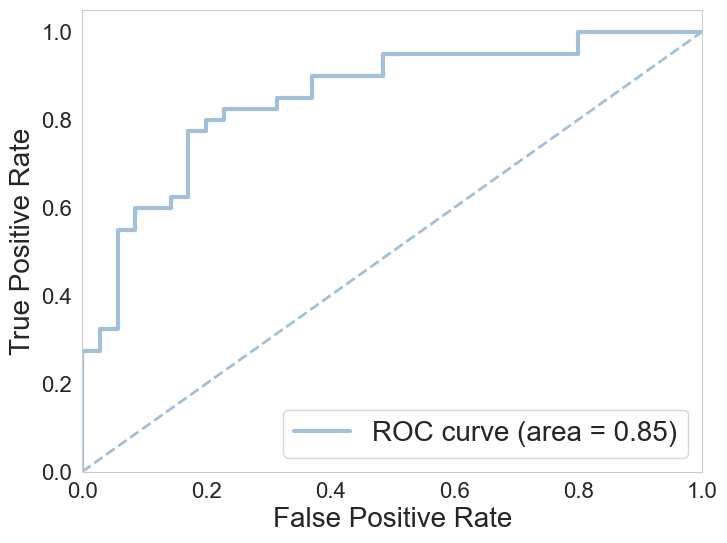

In [48]:
y_pred = best_et.predict_proba(Xtest)[:, 1]

fpr, tpr, thresholds = roc_curve(ytest, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr, tpr, 
    color='#A2C0D9', 
    label='ROC curve (area = {:.2f})'.format(roc_auc),
    linewidth=3
)

plt.plot(
    [0, 1], [0, 1], 
    color='#A2C0D9', 
    linestyle='--', 
    linewidth=2
)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=20)
plt.ylabel('True Positive Rate', fontsize=20)
plt.legend(loc='lower right', fontsize=20)
plt.tick_params(axis='both', labelsize=16)

plt.grid()
plt.savefig('mel_ML.svg', dpi=700, bbox_inches='tight')
plt.show()

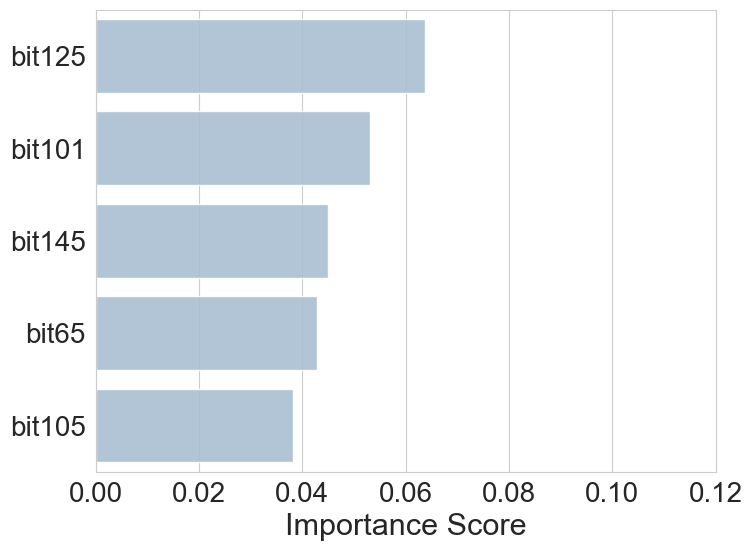

In [49]:
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_et.feature_importances_
}).sort_values(by='Importance', ascending=False)

top5_df = feature_importance_df.head(5)

sns.set_style("whitegrid")
plt.figure(figsize=(8, 6))

bar_color = '#A2C0D9'
sns.barplot(x='Importance', y='Feature', data=top5_df, color=bar_color, alpha=0.9)

plt.xlabel('Importance Score', fontsize=22)
plt.ylabel('')
plt.xlim(0,0.12)
plt.tick_params(axis='x', labelsize=20)
plt.tick_params(axis='y', labelsize=20)
plt.savefig('mel_FI.svg', dpi=700, bbox_inches='tight')
plt.show()

## Save model

In [50]:
import joblib
joblib.dump(best_et, 'best_model_melanin.pkl')

['best_model_melanin.pkl']

## Scaffold split

In [51]:
def to_maccs(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    return np.array(list(MACCSkeys.GenMACCSKeys(mol).ToBitString()), dtype=int)

df['fp'] = df['SMILES'].apply(to_maccs)
df_all = df[df['fp'].notnull()].reset_index(drop=True)
print('Compounds with valid fingerprints:', len(df_all))

Compounds with valid fingerprints: 780


In [52]:
def morgan_fp(smi, radius=2, nbits=2048):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    return AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nbits)

def scaffold_of(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    try:
        scaf = MurckoScaffold.GetScaffoldForMol(mol)
        return Chem.MolToSmiles(scaf)
    except Exception:
        return None

def scaffold_split(smiles_list, test_size=0.2, seed=42):
    scaffolds = {}
    for idx, smi in enumerate(smiles_list):
        s = scaffold_of(smi)
        scaffolds.setdefault(s, []).append(idx)
    groups = list(scaffolds.values())
    rng = np.random.RandomState(seed)
    order = rng.permutation(len(groups))
    groups = [groups[i] for i in order]
    groups.sort(key=len, reverse=True)
    n_total = len(smiles_list)
    n_test_target = int(round(n_total * test_size))
    test_idx, train_idx = [], []
    for g in groups:
        if len(test_idx) < n_test_target:
            test_idx.extend(g)
        else:
            train_idx.extend(g)
    return np.array(train_idx), np.array(test_idx)

def nn_tanimoto_stats(train_smiles, test_smiles):
    train_fps = [morgan_fp(s) for s in train_smiles]
    train_fps = [f for f in train_fps if f is not None]
    sims = []
    for s in test_smiles:
        fp = morgan_fp(s)
        if fp is None or len(train_fps) == 0:
            continue
        bulk = DataStructs.BulkTanimotoSimilarity(fp, train_fps)
        sims.append(max(bulk))
    sims = np.array(sims)
    return {
        'mean_NN_Tanimoto': float(np.mean(sims)) if len(sims) else np.nan,
        'median_NN_Tanimoto': float(np.median(sims)) if len(sims) else np.nan,
        'frac_test_with_NN>0.85': float(np.mean(sims > 0.85)) if len(sims) else np.nan,
    }

In [53]:
def eval_model(Xtr,ytr,Xte,yte, sm_tr, sm_te, label, model=None):
    if model is None:
        model = ExtraTreesClassifier(bootstrap=False, max_depth=None, min_samples_leaf=4,
                                      min_samples_split=10, n_estimators=50, random_state=42)
    model.fit(Xtr, ytr)
    proba = model.predict_proba(Xte)[:,1]
    pred = model.predict(Xte)
    auc_ = roc_auc_score(yte, proba)
    f1_ = f1_score(yte, pred)
    acc_ = accuracy_score(yte, pred)
    sims = nn_tanimoto_stats(sm_tr, sm_te)
    print(f"--- {label} ---")
    print(f"  n_train={len(ytr)} n_test={len(yte)} train_pos_frac={np.mean(ytr):.2f} test_pos_frac={np.mean(yte):.2f}")
    print(f"  ROC-AUC={auc_:.3f}  F1={f1_:.3f}  Acc={acc_:.3f}")
    print(f"  NN-Tanimoto: mean={sims['mean_NN_Tanimoto']:.3f} median={sims['median_NN_Tanimoto']:.3f} "
          f"frac>0.85={sims['frac_test_with_NN>0.85']:.2f}")
    return dict(label=label, auc=auc_, f1=f1_, acc=acc_, **sims)

all_results = []

print("="*70)
print("APPROACH A: original — downsample majority 607->200, then random/scaffold split")
X_ds = np.stack(df_dinal.merge(df_all[['SMILES','fp']], on='SMILES', how='left')['fp'])
y_ds = df_dinal['Class'].values
sm_ds = df_dinal['SMILES'].values
idx_ds = np.arange(len(df_dinal))
tr,te = train_test_split(idx_ds, test_size=0.2, random_state=42, stratify=y_ds)
all_results.append(eval_model(X_ds[tr],y_ds[tr],X_ds[te],y_ds[te], sm_ds[tr], sm_ds[te], "A1: random split, downsampled (orig)"))
tr_s, te_s = scaffold_split(sm_ds, test_size=0.2, seed=42)
all_results.append(eval_model(X_ds[tr_s],y_ds[tr_s],X_ds[te_s],y_ds[te_s], sm_ds[tr_s], sm_ds[te_s], "A2: scaffold split, downsampled"))

APPROACH A: original — downsample majority 607->200, then random/scaffold split
--- A1: random split, downsampled (orig) ---
  n_train=298 n_test=75 train_pos_frac=0.54 test_pos_frac=0.53
  ROC-AUC=0.844  F1=0.779  Acc=0.773
  NN-Tanimoto: mean=0.355 median=0.328 frac>0.85=0.00
--- A2: scaffold split, downsampled ---
  n_train=298 n_test=75 train_pos_frac=0.51 test_pos_frac=0.64
  ROC-AUC=0.819  F1=0.782  Acc=0.747
  NN-Tanimoto: mean=0.315 median=0.304 frac>0.85=0.00
